In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from evals_pkg.evals.metrics import (
    evaluate_predicted_interactions,
    InteractionMetrics,
    evaluate_predicted_observations,
    ObservationMetrics,
)
import numpy as np

def generate_data():
    seed = 8
    np.random.seed(seed)

    n_timepoints = 100
    n_cells = 5

    lower_bound = 0
    upper_bound = 100

    timepoints = np.random.uniform(low=lower_bound, high=upper_bound, size=(n_timepoints))
    W = np.zeros((n_timepoints, n_cells, n_cells))

    W[:, 0, 0] = 1
    W[:, 1, 1] = 1
    W[:, 4, 0] = np.cos(timepoints/30)
    W[:, 2, 1] = np.cos((timepoints - 10)/30)
    W[:, 3, 0] = np.cos((timepoints + 20)/40)
    W[:, 3, 1] = np.cos((timepoints + 20)/40)
    W[:, 4, 2] = np.cos((timepoints + 10)/40)

    epsilon = np.random.normal(0, 0.5, (n_timepoints, n_cells))

    c1 = 0.5 * (np.cos((timepoints + 5)/3) + np.cos(timepoints/5)) + epsilon[:, 0]
    c2 = np.sin((timepoints + 1)/2) + np.cos(timepoints/3) + np.cos((timepoints + 0.5)/3) + epsilon[:, 1]
    
    c3 = W[:, 2, 1] * c2 + epsilon[:, 2]
    c4 = W[:, 3, 0] * c1 + W[:, 3, 1] * c2 + epsilon[:, 3]
    c5 = W[:, 4, 2] * c3 + W[:, 4, 0] * c1 + epsilon[:, 4]

    c1 = c1-np.mean(c1,axis=0)
    c2 = c2-np.mean(c2,axis=0)
    c3 = c3-np.mean(c3,axis=0)
    c4 = c4-np.mean(c4,axis=0)
    c5 = c5-np.mean(c5,axis=0)

    data = np.stack([c1, c2, c3, c4, c5], axis=1)
    
    print(data.shape)
    # Randomly drop data points
    #mask = np.random.rand(n_timepoints) > 0.2
    #data = data[mask]

    # sorty by timepoints
    sort_idx = np.argsort(timepoints)
    data = data[sort_idx,:]
    timepoints = timepoints[sort_idx]
    W = W[sort_idx,:,:]

    lambda_matrix = np.zeros((n_cells, n_cells))
    lambda_matrix[0, 0] = 1
    lambda_matrix[0, 1] = 1
    lambda_matrix[0, 2] = 1
    lambda_matrix[0, 3] = 1
    lambda_matrix[0, 4] = 1
    lambda_matrix[1, 1] = 1
    lambda_matrix[1, 2] = 1
    lambda_matrix[1, 3] = 1
    lambda_matrix[2, 4] = 1

    return timepoints, data, W, lambda_matrix.T

timepoints, data, W, lambda_matrix = generate_data()
print(lambda_matrix)


(100, 5)
[[1. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0.]]


In [2]:
lambda_matrix = np.zeros((5, 5))
lambda_matrix[0, 0] = 1
lambda_matrix[0, 1] = 1
lambda_matrix[0, 2] = 1
lambda_matrix[0, 3] = 1
lambda_matrix[0, 4] = 1
lambda_matrix[1, 1] = 1
lambda_matrix[1, 2] = 1
lambda_matrix[1, 3] = 1
lambda_matrix[2, 4] = 1
print(lambda_matrix.T)

[[1. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0.]]


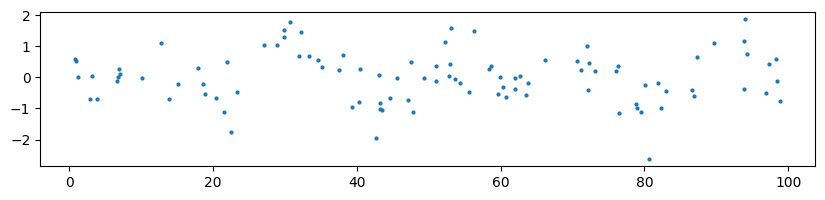

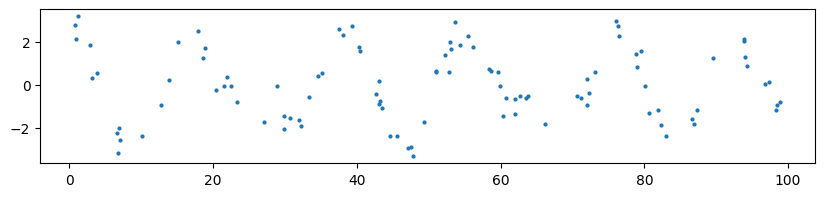

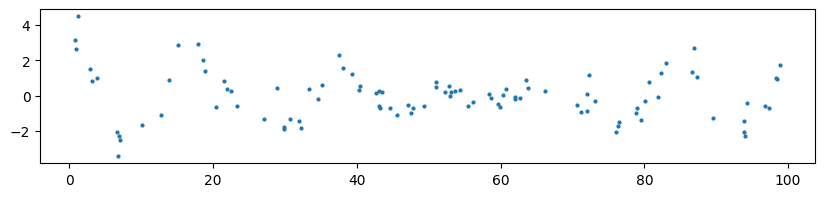

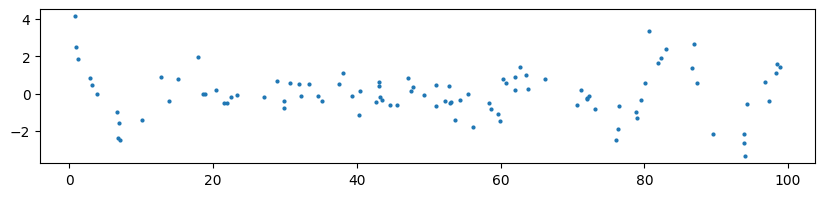

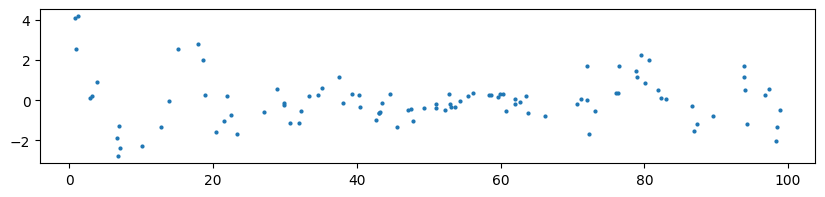

In [3]:
plt.figure(figsize = (10,2))
plt.scatter(timepoints, data[:,0], s = 4)
plt.show()

plt.figure(figsize = (10,2))
plt.scatter(timepoints, data[:,1], s = 4)
plt.show()

plt.figure(figsize = (10,2))
plt.scatter(timepoints, data[:,2], s = 4)
plt.show()

plt.figure(figsize = (10,2))
plt.scatter(timepoints, data[:,3], s = 4)
plt.show()

plt.figure(figsize = (10,2))
plt.scatter(timepoints, data[:,4], s = 4)
plt.show()

In [ ]:
# P_arr = [0.2,0.4,0.6,0.7,0.8,0.9]
# P_arr = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
P_arr = [
    10
]
import random
for iter in range(10):
    for P in P_arr:
        print(f'{P} DROPPED TIMEPOINTS, ITERATION {iter}--------------------------------------------------------------------------')
        print('--------------------------------------------------------------------------------------------------------------')
        # print(P, int(np.floor(P*len(timepoints))))
        timepoints, data, W, lambda_matrix = generate_data()
        drop_timepoints = random.sample(range(len(timepoints)), P)
        # np.random.randint(low = 0, high = len(timepoints), size=P)
        timepoints = np.delete(timepoints,drop_timepoints)
        data = np.delete(data,drop_timepoints, axis = 0)
        W = np.delete(W,drop_timepoints, axis = 0)
        print(data.shape)
        from evals_pkg.evals.generate_data import create_true_interactions_from_dependent_computations, create_model_prior_from_true_interactions
        true_interactions = create_true_interactions_from_dependent_computations(
            W, 0.1
        )
        model_prior = create_model_prior_from_true_interactions(
            true_interactions, 0, 0
        )

        from diisco import names
        
        hyper_init_vals = {
            names.LENGTHSCALE_F: 5,
            names.LENGTHSCALE_W: 30,
            names.SIGMA_F: 0.5,
            names.VARIANCE_F: 3,
            names.SIGMA_W: 0.1,
            names.VARIANCE_W: 10,
            names.SIGMA_Y: 0.1,
        }
        
        from diisco import DIISCO
        model = DIISCO(**config)
        
        model.fit(timepoints=timepoints, proportions=data, n_iter=15000, guide="MultivariateNormalFactorized")
        
        interaction_score = model.predict_obs_interactions()
        # interaction_score_dict_2[P] = interaction_score
        interaction_metrics: InteractionMetrics = evaluate_predicted_interactions(
            true_interactions=true_interactions,
            interaction_score=interaction_score,
            observations=data,
            timepoints=timepoints,
        )
        
        # # print("\n\ninteraction_score", interaction_score.astype(int)[0])
        # # print("\n\ntrue_interactions", dataset.true_interactions.astype(int)[0])
        
        true_observations = data
        predicted_observations = model.predict_y_train()
        
        # # print("\n\ntrue_observations", true_observations)
        # # print("\n\npredicted_observations", predicted_observations)
        
        observation_metrics: ObservationMetrics = evaluate_predicted_observations(
            true_observations=true_observations,
            predicted_observations=predicted_observations,
        )
    
        observation_metrics_interactions: ObservationMetrics = evaluate_predicted_observations(
            true_observations=W,
            predicted_observations=interaction_score[:,:,:],
        )
    
    
        sample_dict,time_points = model.get_predictions()
        time_points = time_points.squeeze().numpy()
        
        W_samples_predict = sample_dict['W']
        y_samples_predict = sample_dict['Y']
        f_samples_predict = sample_dict['F']
        
        
        ### PLOT 
        
        n = 5; max_cols = 3
        nrows = int(np.ceil(n / max_cols)); ncols = int(min((max_cols, n)))
        fig = plt.figure(figsize=[7 * ncols, 4 * nrows])
        for i in range(5):
            ax = fig.add_subplot(nrows, ncols, i+1)
            y = data[:,i]
            # if np.max(np.abs(y)) < 0.05: continue
            ax.scatter(timepoints,y, s = 30)
            y_pred = y_samples_predict[:,:,i].mean(axis = 0)
            ax.plot(time_points,y_pred)
            ax.set_title(f'{i} dynamics')
            # ax.set_ylim((np.min(y_pred)-0.3,np.max(y_pred)+0.3))
            percentile_75 = np.percentile(y_samples_predict[:,:,i], 95, axis=0)
            percentile_25 = np.percentile(y_samples_predict[:,:,i], 5, axis=0)
            ax.fill_between(time_points, percentile_25, percentile_75, alpha=0.2)
        # plt.suptitle(f"ground truth dynamics vs diisco predictions")
        plt.show()
        
        
        interaction_plots = []
        for i in range(5):
            for j in range(5):
                # print(i,j)
                if i == j: continue
                y = W_samples_predict[:, :,i, j].detach().numpy()
                if np.max(np.abs(y)) > 0.005: 
                    interaction_plots.append([i,j])
                    
        n = len(interaction_plots); max_cols = 4
        nrows = int(np.ceil(n / max_cols)); ncols = int(min((max_cols, n)))
        fig = plt.figure(figsize=[5 * ncols, 4 * nrows])
        for i,interaction in enumerate(interaction_plots):
            ax = fig.add_subplot(nrows, ncols, i+1)
            y = W[:,interaction[0],interaction[1]]
            ax.scatter(timepoints,y, s = 30)
            ax.plot(time_points, 
                             W_samples_predict[:, :,interaction[0], interaction[1]].mean(axis=0))
            ax.set_title(f'{interaction} interaction')
            ax.set_ylim(-2.5,2.5)
        plt.suptitle("ground truth interactions")
        plt.show()

10 DROPPED TIMEPOINTS, ITERATION 0--------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------
(100, 5)
(90, 5)
{'min_points_per_regression': 3, 'num_searches_per_timepoint': 10, 'use_bias': False, 'epsilon': 0.5, 'ignore_is_active': True, 'ignore_epsilon': False}


TypeError: Use () not None as shape arguments

In [ ]:
true_interactions

In [ ]:
from sklearn.metrics import roc_curve
tpr,fpr,threshold = roc_curve(np.array(true_interactions.astype(int).flatten()), interactions, pos_label = 1)

In [ ]:
plt.plot(tpr,fpr)

In [ ]:
interactions = np.array(interaction_metrics.transformed_interactions)
interactions[interactions>=1] = 1
interactions[interactions<1] = 0
interactions

In [ ]:
interactions

In [ ]:
 W_samples_predict[:, timepoints ,interaction[0], interaction[1]].mean(axis=0)

In [ ]:
plt.scatter(timepoints, W_samples_predict[:, timepoints ,interaction[0], interaction[1]].mean(axis=0))
plt.scatter(timepoints, W[:,4,2])

In [ ]:
timepoints

In [ ]:
observation_metrics_interactions: ObservationMetrics = evaluate_predicted_observations(
        true_observations=W,
        predicted_observations=W_samples_predict[:,timepoints,:,:].mean(axis = 0),
    )

In [ ]:
observation_metrics

In [ ]:
r2_score(W.flatten(), predicted_observations.flatten())

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    roc_curve
)

# roc_curve(W[:,4,0],W_samples_predict[:,timepoints,4,0].mean(axis = 0))

